In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn import preprocessing
from scipy import stats

In [3]:
data = pd.read_excel('data/Pyrolysis_Data 6-16_Reduced.xlsx').drop(['Unnamed: 0'], axis=1)

data.describe()

,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
count,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,...,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000
mean,52086.607262,8712.582010,8287.932362,8842.522833,8603.680748,8444.248226,8865.866092,4297.905730,4452.905547,4365.018466,...,617.811929,622.511101,831.648208,836.780286,835.400132,836.319523,837.300782,837.903612,1027.474983,837.910011
std,464.738337,121.623591,120.638306,95.786130,107.469695,112.196548,106.172983,40.376338,42.363111,24.027639,...,3.940449,2.917192,1.910854,2.236806,1.922875,1.811575,2.094034,2.244648,10.038618,1.285605
min,45736.531250,7466.118164,7110.184570,7652.420410,7561.086914,7439.499512,7731.586426,4147.067871,4204.664050,4241.510682,...,603.491333,611.425110,804.398743,809.329590,810.840485,812.086029,811.762329,811.068130,980.803802,813.534363
25%,52080.425781,8674.464844,8250.759766,8816.666992,8557.800781,8409.102539,8819.564453,4277.095703,4445.440693,4351.510742,...,614.694580,620.329590,830.853425,836.122177,834.470825,835.493164,836.341479,836.836578,1019.737488,837.743379
50%,52136.097656,8731.911133,8286.455078,8849.289062,8605.119141,8459.644902,8884.833008,4288.175293,4462.412109,4363.266113,...,618.976257,622.934143,831.628510,836.826157,835.474991,836.345734,837.407837,838.015167,1029.567841,837.979076
75%,52197.140625,8777.038086,8320.266851,8883.692383,8672.966798,8504.736328,8927.785156,4300.790039,4474.368161,4376.137695,...,620.939880,624.776917,832.425751,837.532196,836.445328,837.252701,838.400406,839.075317,1035.154907,838.240967
max,53489.472656,9053.129883,9278.496829,9080.204688,8854.346362,8805.973330,9129.166016,4469.789062,4630.651488,4493.321627,...,625.199951,629.285583,846.023840,865.560687,845.728282,843.780106,846.446014,850.595634,1045.856140,841.106018


In [5]:
x = data.values #returns a numpy array
min_max_scaler = preprocessing.MinMaxScaler()
standard_scaler = preprocessing.StandardScaler()

x_min_max_scaled = min_max_scaler.fit_transform(x)
x_standard_scaled = standard_scaler.fit_transform(x)

min_max_data = pd.DataFrame(x_min_max_scaled)
min_max_data.columns = data.columns

standard_data = pd.DataFrame(x_standard_scaled)
standard_data.columns = data.columns

In [7]:
data.head()


,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,52221.634263,8326.643312,8514.593137,8772.479316,8702.662279,8725.061214,8925.859148,4231.776051,4235.679965,4331.376363,...,611.155410,617.949135,835.685702,832.775546,837.579875,835.185782,837.532533,840.083022,1014.203860,838.564984
1,52265.900328,8365.639417,8556.450386,8785.182039,8691.885549,8703.588278,8947.979539,4234.084322,4235.981084,4331.812712,...,608.830187,615.503000,842.786275,857.657809,842.063391,831.472131,827.847198,829.859649,1003.212185,838.303879
2,52175.422216,8399.151486,8958.929290,8866.258307,8568.940794,8487.709325,8657.917877,4219.596998,4227.073918,4335.506624,...,612.223660,619.237611,832.882358,829.082685,836.141160,835.556342,839.504382,844.880867,1012.859396,837.527600
3,52301.058592,8371.304905,8755.843789,8816.456687,8648.966226,8614.722260,8805.725760,4235.860665,4242.020290,4330.784367,...,610.773671,617.620987,836.430164,833.785133,840.057993,838.177957,834.462237,833.534243,1011.943218,837.818136
4,52294.353809,8395.126075,8939.937799,8868.780738,8602.885921,8493.646648,8679.958967,4240.078093,4221.425555,4324.309267,...,610.275413,617.500575,839.643744,851.533809,842.807576,835.302639,827.123134,825.370441,1005.692422,837.338927


In [9]:
min_max_data.head()

,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,0.836470,0.542230,0.647697,0.784473,0.882712,0.940788,0.854529,0.262481,0.072809,0.356878,...,0.353043,0.365277,0.751637,0.416957,0.766440,0.728835,0.743007,0.734043,0.513434,0.907839
1,0.842180,0.566802,0.667001,0.793370,0.874379,0.925074,0.870357,0.269634,0.073516,0.358610,...,0.245932,0.228319,0.922221,0.859457,0.894952,0.611663,0.463759,0.475404,0.344467,0.898369
2,0.830509,0.587918,0.852619,0.850155,0.779313,0.767091,0.662811,0.224742,0.052607,0.373280,...,0.402252,0.437418,0.684289,0.351284,0.725201,0.740527,0.799859,0.855423,0.492766,0.870214
3,0.846714,0.570372,0.758959,0.815275,0.841192,0.860040,0.768571,0.275138,0.087693,0.354527,...,0.335458,0.346904,0.769522,0.434911,0.837471,0.823243,0.654484,0.568367,0.478683,0.880751
4,0.845850,0.585382,0.843861,0.851922,0.805561,0.771436,0.678582,0.288206,0.039347,0.328812,...,0.312506,0.340163,0.846725,0.750549,0.916283,0.732522,0.442883,0.361832,0.382594,0.863371


In [10]:
standard_data.head()

,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,0.290566,-3.173460,1.878987,-0.731304,0.921087,2.503054,0.565092,-1.637955,-5.128091,-1.400247,...,-1.689406,-1.563938,2.113085,-1.790518,1.133670,-0.625878,0.110680,0.971009,-1.322106,0.509505
1,0.385823,-2.852807,2.225978,-0.598678,0.820803,2.311653,0.773451,-1.580782,-5.120982,-1.382085,...,-2.279541,-2.402525,5.829279,9.334333,3.465518,-2.675989,-4.514871,-3.583888,-2.417127,0.306391
2,0.191122,-2.577247,5.562472,0.247815,-0.323278,0.387395,-1.958726,-1.939616,-5.331255,-1.228338,...,-1.418287,-1.122222,0.645912,-3.441594,0.385404,-0.421312,1.052402,3.108630,-1.456045,-0.297479
3,0.461480,-2.806221,3.878921,-0.272149,0.421411,1.519537,-0.566480,-1.536784,-4.978413,-1.424887,...,-1.786290,-1.676434,2.502710,-1.339132,2.422523,1.025943,-1.355641,-1.946718,-1.547318,-0.071470
4,0.447052,-2.610347,5.405035,0.274151,-0.007396,0.440318,-1.751115,-1.432323,-5.464597,-1.694393,...,-1.912747,-1.717714,4.184587,6.596295,3.852564,-0.561368,-4.860671,-5.583999,-2.170039,-0.444247


In [11]:
def plot_distribution(data, color = 'b'):

    fig = plt.figure(figsize=(15, 6))

    axes = []

    if data is not None:
        for i, col in enumerate(data.columns):
            ax = fig.add_subplot(len(data.columns), int(np.floor(len(data.columns) + 1)), i+1)
            lr = min(data[col].values)

            ur = max(data[col].values)

            data[col].plot.hist(ax = ax, bins = 25, range=[lr, ur], color = color)
            ax.set_xlabel(f'{col}', labelpad = 10, fontsize='x-large')
            ax.set_ylabel('')

            ax.grid(False)

            axes.append(ax)


    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.tight_layout()

    plt.show()

    return None


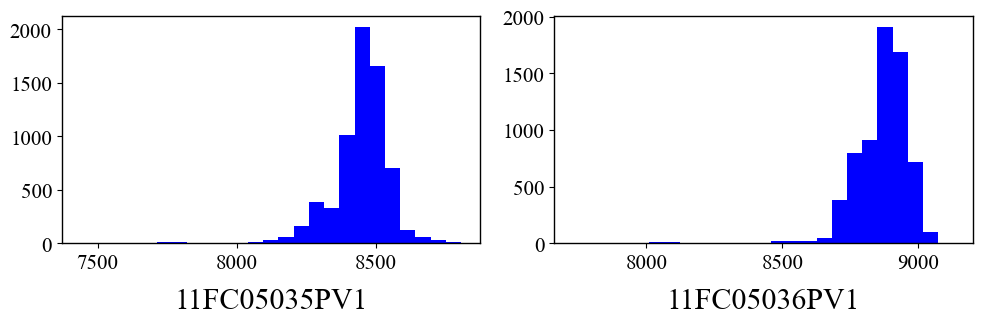

In [13]:
plot_distribution(data.iloc[:, 5:7])

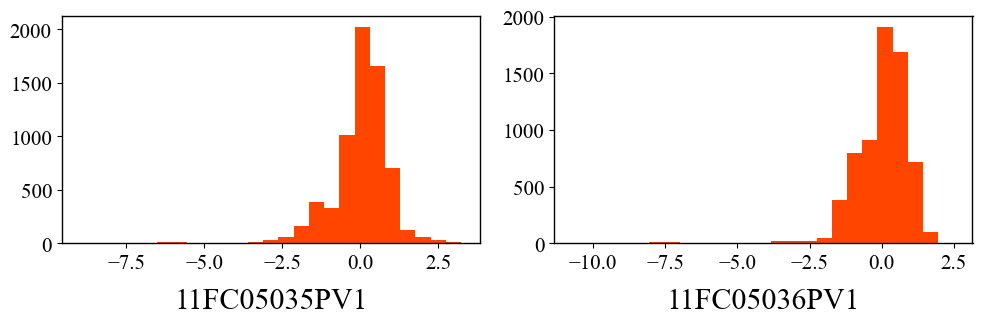

In [15]:
plot_distribution(standard_data.iloc[:, 5:7], color = 'orangered')

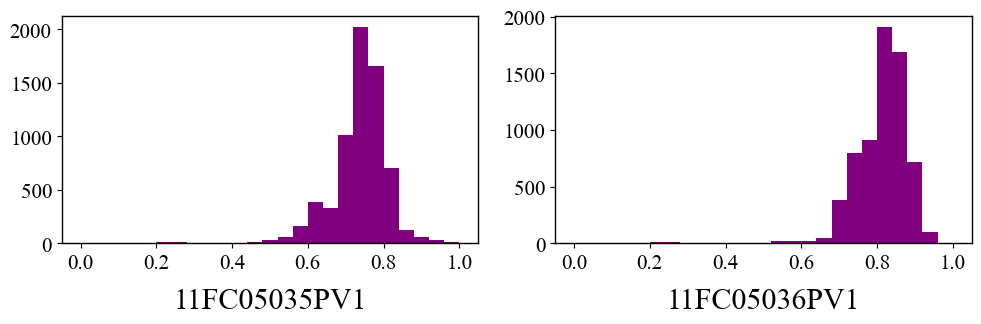

In [17]:
plot_distribution(min_max_data.iloc[:, 5:7], color = 'purple')